# Premier exemple d'utilisation de l'algorithme Hierarchical Refinement (HiRef)


We experiment with the implementation of Hierachical Refinement based on the low-rank LRSinkhorn solver, proposed by [Halmos et al., 2025],  an algorithm to scalably compute a full-rank alignment between two equally-sized input datasets X and Y by solving a hierarchy of low-rank OT.sub-problems. 

___
* L’idée maîtresse de l’article est de construire pas‑à‑pas une bijection entre deux nuages de points en ne manipulant que des sous‑problèmes de transport de rang très faible (r = 2).

* À chaque échelle on découpe (co‑clusterise) les deux jeux de données de manière cohérente, puis on raffine ces blocs jusqu’à obtenir des singletons. 

* L’union des raffinements fournit alors un couplage full‑rank, donc déterministe.

## 1ère partition 
- 2 blocs de 4 points 
- Low rank r=2 
- g uniforme

In [1]:
import jax
import jax.numpy as jnp

In [2]:
# ---------- données jouet : 8 points 2D -------------------------------
def create_points(rng, n, d):
    rngs = jax.random.split(rng, 2)
    x = jax.random.normal(rngs[0], (n, d))
    y = jax.random.uniform(rngs[1], (n, d), minval=4, maxval=8)
    a = 1 / n # Hi ref utilise des distribution uniforme 
    b = a
    return x, y, a, b

In [3]:
rng = jax.random.key(4)
n, d = 10000, 2
x, y, _, _ = create_points(rng, n=n, d=d)

In [4]:
from jax import tree_util
from ott.solvers.linear.sinkhorn_lr import LRSinkhorn

class LRSinkhornUniformG(LRSinkhorn):
    # surcharge partielle pour forcer g uniforme
    def dykstra_update_lse(self, *args, **kwargs):
        q, r, _ = super().dykstra_update_lse(*args, **kwargs)
        g = jnp.ones(self.rank) / self.rank
        return q, r, g

    def dykstra_update_kernel(self, *args, **kwargs):
        q, r, _ = super().dykstra_update_kernel(*args, **kwargs)
        g = jnp.ones(self.rank) / self.rank
        return q, r, g

# Fonctions de flatten/unflatten pour PyTree
def flatten_solver(solver):
    # sélectionnez ici les attributs nécessaires à la reconstruction
    children = (solver.rank,
                solver.gamma,
                solver.epsilon,
                solver.initializer,
                solver.inner_iterations)
    aux = {}
    return children, aux

def unflatten_solver(aux, children):
    rank, gamma, epsilon, initializer, inner_it = children
    return LRSinkhornUniformG(rank=rank,
                              gamma=gamma,
                              epsilon=epsilon,
                              initializer=initializer,
                              inner_iterations=inner_it)

# Enregistrement PyTree
tree_util.register_pytree_node(LRSinkhornUniformG,
                               flatten_solver,
                               unflatten_solver)


In [5]:
import jax
import jax.numpy as jnp
from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.initializers.linear.initializers_lr import Rank2Initializer

def low_rank_ot_uniG(x_block: jnp.ndarray,
                y_block: jnp.ndarray,
                rank: int = 2):
    """Résout un OT de rang `rank` avec g uniforme, renvoie Q, R, g."""
    # Geometry: Euclidean cost
    geom = pointcloud.PointCloud(x_block, y_block)

    # Définir le problème OT linéaire
    ot_prob = linear_problem.LinearProblem(geom)

    # # Initialiseur avec Rank2Initializer pour facteurs Q, R
    initializer = Rank2Initializer(rank=rank)

    # Solver low-rank Sinkhorn compilé via JAX
    solver = LRSinkhornUniformG(rank=rank, gamma=3000,
    initializer=initializer, lse_mode=True)
    
    #solver = jax.jit(LRSinkhornUniformG(rank=rank, initializer=initializer)) La compilation Just in Time ne fonction pas ici
    ot_lr = solver(ot_prob)

    return ot_lr.q, ot_lr.r, ot_lr.g

In [6]:
Q, R, G = low_rank_ot_uniG(x, y, rank=2)

print("Matrice R est de taille :", Q.shape)
print("Matrice Q est de taille :", R.shape)
print("Tous les coefficients de la matrice G doivent valoir 1/rank :", G)

Matrice R est de taille : (10000, 2)
Matrice Q est de taille : (10000, 2)
Tous les coefficients de la matrice G doivent valoir 1/rank : [0.5 0.5]


In [7]:
def partition(x_block, y_block, rank=2, base_size=1, depth=0):
    n = x_block.shape[0]
    if n <= base_size:
        # bloc de taille 1 : retourne l’indice final
        return [(int(depth), int(depth))]   # ici on retourne juste positions internes

    # ====  étape low‑rank  ============================================
    Q, R, g = low_rank_ot_uniG(x_block, y_block, rank=rank)

    # étiquettes du bloc = argmax par ligne
    part_x = jnp.argmax(Q, axis=1)
    part_y = jnp.argmax(R, axis=1) 

    return part_x, part_y, (Q, R, g)

In [8]:
partition_x, partition_y, matrice = partition(x, y, rank=2)


In [9]:
matrice

(Array([[9.89016116e-05, 1.12462067e-06],
        [1.00016296e-04, 1.05410916e-08],
        [6.82375903e-05, 3.17721569e-05],
        ...,
        [6.11088908e-05, 3.88969602e-05],
        [8.14585448e-08, 9.98916148e-05],
        [1.00024496e-04, 2.33205411e-09]], dtype=float32),
 Array([[9.9906094e-05, 6.6828179e-08],
        [9.9970617e-05, 2.2388893e-09],
        [6.6637312e-10, 1.0002660e-04],
        ...,
        [9.9956218e-05, 1.6681650e-08],
        [9.9915815e-05, 5.7031684e-08],
        [1.6940810e-06, 9.8332341e-05]], dtype=float32),
 Array([0.5, 0.5], dtype=float32))

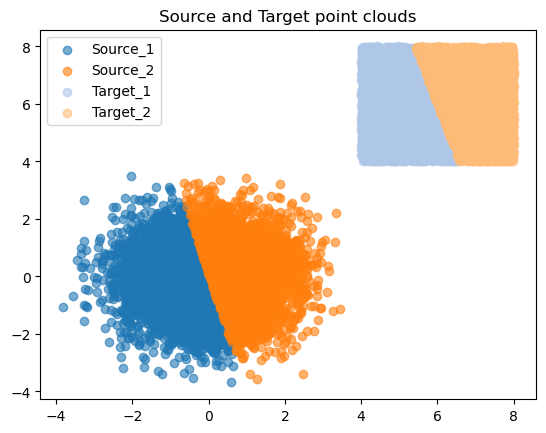

In [10]:
import matplotlib.pyplot as plt

# Supposons que partition_x et partition_y soient des array de labels (0 ou 1)
# Vous vouliez extraire la partition « 1 » pour x, et la partition « 1 » pour y :

mask_x = (partition_x == 1)     # True pour les points de x dans le bloc 1
mask_y = (partition_y == 1)     # True pour les points de y dans le bloc 1

# Utiliser ~mask pour l’inverse du masque :
x1 = x[mask_x]     # éléments de x où partition_x == 1 :contentReference[oaicite:0]{index=0}
x2 = x[~mask_x]    # tous les autres :contentReference[oaicite:1]{index=1}

y1 = y[mask_y]     # éléments de y où partition_y == 1 :contentReference[oaicite:2]{index=2}
y2 = y[~mask_y]    # tous les autres :contentReference[oaicite:3]{index=3}

# Affichage

# Couleurs « proches » dans chaque paire
c_src1 = "#1f77b4"   # bleu foncé
c_tgt1 = "#aec7e8"   # bleu clair

c_src2 = "#ff7f0e"   # orange foncé
c_tgt2 = "#ffbb78"   # orange clair


plt.scatter(x1[:, 0], x1[:, 1], color=c_src1, label="Source_1", alpha=0.6)
plt.scatter(x2[:, 0], x2[:, 1], color=c_src2, label="Source_2", alpha=0.6)

plt.scatter(y1[:, 0], y1[:, 1], color=c_tgt1, label="Target_1", alpha=0.6)
plt.scatter(y2[:, 0], y2[:, 1], color=c_tgt2, label="Target_2", alpha=0.6)

plt.legend()
plt.title("Source and Target point clouds")
plt.show()


In [11]:
print("shape x1 :", x1.shape)
print("shape x2 :", x2.shape)
print("shape y1 :", y1.shape)
print("shape y2 :", y2.shape)

shape x1 : (4983, 2)
shape x2 : (5017, 2)
shape y1 : (5002, 2)
shape y2 : (4998, 2)


## 2ème méthode

In [ ]:
rng = jax.random.key(4)
n, d = 20, 2
x, y, _, _ = create_points(rng, n=n, d=d)

In [32]:
import jax
import jax.numpy as jnp
from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.initializers.linear.initializers_lr import Rank2Initializer
from ott.solvers.linear.sinkhorn_lr import LRSinkhorn

def low_rank_partition(x_block: jnp.ndarray,
                       y_block: jnp.ndarray,
                       rank: int = 2):
    """
    Renvoie pour chaque point de x_block et y_block 
    son indice de cluster {0,1} à rang=2, 
    en initialisant avec Rank2Initializer.
    """
    # 1) Problème OT
    geom    = pointcloud.PointCloud(x_block, y_block)
    n       = x_block.shape[0]
    a       = jnp.ones(n) / n
    ot_prob = linear_problem.LinearProblem(geom)

    # 2) Initialiser avec Rank2Initializer (déterministe)
    init    = Rank2Initializer(rank=rank)

    # 3) Créer le solver low‑rank Sinkhorn
    solver  = jax.jit(LRSinkhorn(rank=rank, initializer=init, gamma=50000))

    # 4) Lancer la résolution (pas besoin de jit pour du debug)
    out     = solver(ot_prob)

    # 5) Les deux soft‑clustering Q et R → argmax pour labels {0,1}
    Q, R, G    = out.q, out.r, out.g

    partition_x = jnp.argmax(Q, axis=1)
    partition_y = jnp.argmax(R, axis=1)

    return partition_x, partition_y, (Q,R,G)

In [33]:
# --- Exemple d’usage ---
partition_x, partition_y, matrice = low_rank_partition(x, y)

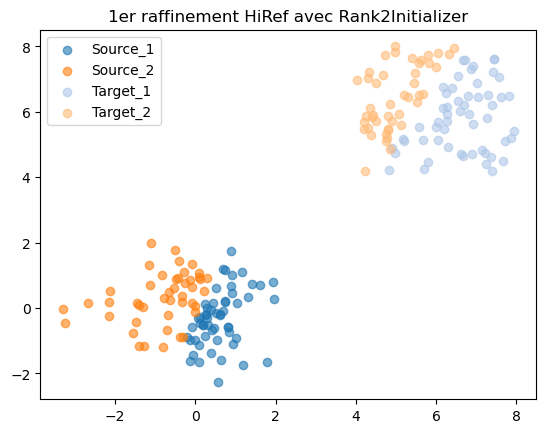

In [34]:
# Masques et affichage
mask_x1 = (partition_x == 0)
mask_x2 = ~mask_x1
mask_y1 = (partition_y == 0)
mask_y2 = ~mask_y1

import matplotlib.pyplot as plt
plt.scatter(x[mask_x1,0], x[mask_x1,1], color="#1f77b4", label="Source_1", alpha=0.6)
plt.scatter(x[mask_x2,0], x[mask_x2,1], color="#ff7f0e", label="Source_2", alpha=0.6)
plt.scatter(y[mask_y1,0], y[mask_y1,1], color="#aec7e8", label="Target_1", alpha=0.6)
plt.scatter(y[mask_y2,0], y[mask_y2,1], color="#ffbb78", label="Target_2", alpha=0.6)
plt.legend(); plt.title("1er raffinement HiRef avec Rank2Initializer"); plt.show()

In [35]:
matrice

(Array([[3.09899089e-38, 9.99501720e-03],
        [1.00041199e-02, 0.00000000e+00],
        [1.00041199e-02, 7.44034732e-27],
        [0.00000000e+00, 9.99481790e-03],
        [0.00000000e+00, 9.99501720e-03],
        [0.00000000e+00, 9.99501720e-03],
        [1.00041199e-02, 5.40644949e-13],
        [1.00041199e-02, 0.00000000e+00],
        [1.00041199e-02, 0.00000000e+00],
        [0.00000000e+00, 9.99481790e-03],
        [0.00000000e+00, 9.99491755e-03],
        [1.00041199e-02, 0.00000000e+00],
        [1.00043202e-02, 7.23465068e-22],
        [0.00000000e+00, 9.99481790e-03],
        [0.00000000e+00, 9.99481790e-03],
        [1.00041199e-02, 0.00000000e+00],
        [1.00041199e-02, 0.00000000e+00],
        [0.00000000e+00, 9.99481790e-03],
        [0.00000000e+00, 9.99501720e-03],
        [8.26264210e-29, 9.99501720e-03],
        [1.00041199e-02, 0.00000000e+00],
        [0.00000000e+00, 9.99501720e-03],
        [1.00041199e-02, 0.00000000e+00],
        [1.00043202e-02, 9.2638855

In [44]:
def hiref(x: jnp.ndarray,
          y: jnp.ndarray,
          x_idx: jnp.ndarray = None,
          y_idx: jnp.ndarray = None,
          rank: int = 2,
          base_size: int = 1):
    """
    Hierarchical Refinement: retourne une liste de couples (i,j)
    où i,j sont des indices dans le dataset original.
    """
    # Initialisation des index originaux
    if x_idx is None:
        x_idx = jnp.arange(x.shape[0])
    if y_idx is None:
        y_idx = jnp.arange(y.shape[0])

    n = x.shape[0]
    # Cas de base : bloc de taille 1 → on mappe directement les deux points
    if n <= base_size:
        return [(int(x_idx[0]), int(y_idx[0]))]

    # 1) Partition low-rank rang=2
    lab_x, lab_y, matrice = low_rank_partition(x, y, rank=rank)

    pairs = []
    # 2) Pour chaque sous-bloc z=0 et z=1
    for z in range(rank):
        mask_x    = (lab_x == z)
        mask_y    = (lab_y == z)
        x_sub     = x[mask_x]
        y_sub     = y[mask_y]
        x_idx_sub = x_idx[mask_x]
        y_idx_sub = y_idx[mask_y]

        # 3) Récursion
        pairs.extend(hiref(x_sub, y_sub,
                           x_idx=x_idx_sub,
                           y_idx=y_idx_sub,
                           rank=rank,
                           base_size=base_size))
    return pairs

In [46]:
pairs = hiref(x, y, base_size=1)

# 4) Construction de la matrice de transport bijective P ∈ {0,1}^{N×N}
N = x.shape[0]
P = jnp.zeros((N, N), dtype=jnp.int32)
for i, j in pairs:
    P = P.at[i, j].set(1)

# 5) Vérification
assert jnp.all(P.sum(axis=1) == 1)
assert jnp.all(P.sum(axis=0) == 1)

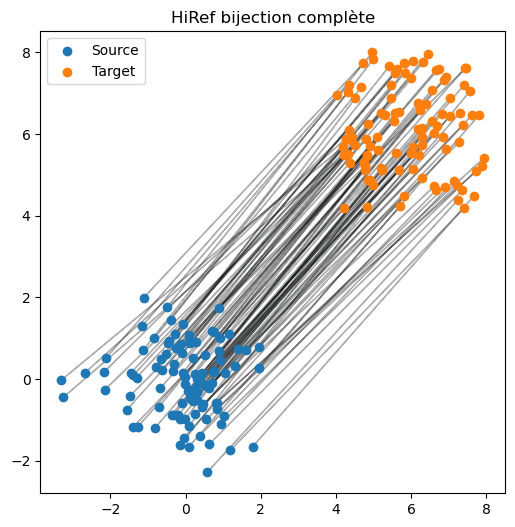

In [47]:
plt.figure(figsize=(6,6))
for i, j in pairs:
    plt.arrow(x[i,0], x[i,1],
              y[j,0] - x[i,0],
              y[j,1] - x[i,1],
              head_width=0.05, alpha=0.3, length_includes_head=True)
plt.scatter(x[:,0], x[:,1], c='C0', label='Source')
plt.scatter(y[:,0], y[:,1], c='C1', label='Target')
plt.legend(); plt.title("HiRef bijection complète"); plt.show()